# Eye Blink Detection using MediaPipe Face Landmarker Tasks API

This notebook demonstrates how to implement **Eye Blink Detection** using facial landmarks extracted by the modern **MediaPipe Tasks API** (`mediapipe.tasks.python.vision`).

## 1. Mathematical Concept: Eye Aspect Ratio (EAR)
Eye blink detection is commonly achieved using the **Eye Aspect Ratio (EAR)**. First introduced by Soukupová and Čech in 2016, EAR uses the distances between vertical and horizontal eye landmarks to determine if the eye is open or closed.

For an eye represented by 6 landmarks (where $p_1, p_4$ are the horizontal corners, and $p_2, p_3, p_5, p_6$ are the vertical pairs):

$$\text{EAR} = \frac{||p_2 - p_6|| + ||p_3 - p_5||}{2 \cdot ||p_1 - p_4||}$$

In MediaPipe's 478-landmark Face Mesh, we use 8 landmarks per eye to get a more robust horizontal and vertical representation by averaging 3 vertical pairs:

$$\text{EAR} = \frac{||p_{top1} - p_{bottom1}|| + ||p_{top2} - p_{bottom2}|| + ||p_{top3} - p_{bottom3}||}{3 \cdot ||p_{left} - p_{right}||}$$

- When the eye is **open**, the EAR remains relatively constant (usually between `0.22` and `0.30`).
- When the eye **blinks/closes**, the vertical distances rapidly approach zero, causing the EAR to drop significantly (typically below `0.12`).

## 2. Import Dependencies & Set Up Assets

We import our required libraries and ensure the `face_landmarker.task` model file and `face_test.jpg` image are available.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("MediaPipe version:", mp.__version__)

# Ensure assets exist in current directory or parent directory
model_path = "face_landmarker.task"
image_path = "face_test.jpg"

if not os.path.exists(model_path):
    # Check in parent directory or download
    if os.path.exists(os.path.join("..", model_path)):
        model_path = os.path.join("..", model_path)
    else:
        import requests
        print("Downloading face_landmarker.task...")
        url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
        r = requests.get(url, timeout=30)
        with open(model_path, "wb") as f:
            f.write(r.content)
        print("Download complete.")

if not os.path.exists(image_path):
    if os.path.exists(os.path.join("..", image_path)):
        image_path = os.path.join("..", image_path)
    else:
        # Generate minimal placeholder face image
        print("Generating placeholder face image...")
        img_face = np.ones((480, 400, 3), dtype=np.uint8) * 200
        cv2.ellipse(img_face, (200, 200), (120, 160), 0, 0, 360, (200, 170, 140), -1)
        cv2.circle(img_face, (160, 180), 20, (80, 60, 40), -1)  # left eye
        cv2.circle(img_face, (240, 180), 20, (80, 60, 40), -1)  # right eye
        cv2.ellipse(img_face, (200, 280), (40, 20), 0, 0, 180, (100, 60, 60), 3)  # mouth
        cv2.imwrite(image_path, img_face)

print(f"Using model: {os.path.abspath(model_path)}")
print(f"Using test image: {os.path.abspath(image_path)}")

MediaPipe version: 0.10.35
Using model: c:\Users\xinod\Documents\Projects\CEC616\scripts\CA\face_landmarker.task
Using test image: c:\Users\xinod\Documents\Projects\CEC616\scripts\CA\face_test.jpg


## 3. Defining Eye Landmark Indices

MediaPipe Face Mesh outputs 478 3D landmarks. We map the specific indices for both left and right eyes to perform EAR calculations.

* **Left Eye Indices** (from camera's view of the subject's left eye):
  - Horizontal corners: `362` (inner/right corner), `263` (outer/left corner)
  - Vertical top: `385`, `386`, `387`
  - Vertical bottom: `380`, `374`, `373`

* **Right Eye Indices** (from camera's view of the subject's right eye):
  - Horizontal corners: `33` (outer/right corner), `133` (inner/left corner)
  - Vertical top: `160`, `159`, `158`
  - Vertical bottom: `144`, `145`, `153`

In [2]:
# Left Eye indices
LEFT_EYE_HORIZONTAL = [362, 263]
LEFT_EYE_VERTICAL_TOP = [385, 386, 387]
LEFT_EYE_VERTICAL_BOTTOM = [380, 374, 373]

# Right Eye indices
RIGHT_EYE_HORIZONTAL = [33, 133]
RIGHT_EYE_VERTICAL_TOP = [160, 159, 158]
RIGHT_EYE_VERTICAL_BOTTOM = [144, 145, 153]

## 4. EAR Calculation Function

Let's write a clean function to compute EAR using the Euclidean distance between the 3D landmark coordinates.

In [3]:
def calculate_ear(landmarks, horizontal_indices, vertical_top_indices, vertical_bottom_indices):
    """
    Calculates the Eye Aspect Ratio (EAR) for a single eye.
    
    Parameters:
        landmarks (list): The list of face landmarks from MediaPipe.
        horizontal_indices (list): List of 2 indices representing horizontal corners.
        vertical_top_indices (list): List of 3 indices representing top vertical landmarks.
        vertical_bottom_indices (list): List of 3 indices representing bottom vertical landmarks.
        
    Returns:
        float: The computed EAR value.
    """
    # Retrieve 3D point coordinates (x, y, z)
    p_h1 = np.array([landmarks[horizontal_indices[0]].x, landmarks[horizontal_indices[0]].y, landmarks[horizontal_indices[0]].z])
    p_h2 = np.array([landmarks[horizontal_indices[1]].x, landmarks[horizontal_indices[1]].y, landmarks[horizontal_indices[1]].z])
    
    # Calculate sum of distances for the three vertical landmark pairs
    vertical_dist_sum = 0.0
    for top_idx, bottom_idx in zip(vertical_top_indices, vertical_bottom_indices):
        p_top = np.array([landmarks[top_idx].x, landmarks[top_idx].y, landmarks[top_idx].z])
        p_bottom = np.array([landmarks[bottom_idx].x, landmarks[bottom_idx].y, landmarks[bottom_idx].z])
        vertical_dist_sum += np.linalg.norm(p_top - p_bottom)
        
    # Calculate horizontal distance
    horizontal_dist = np.linalg.norm(p_h1 - p_h2)
    
    # Avoid division by zero
    if horizontal_dist == 0:
        return 0.0
        
    # EAR Formula (normalized across 3 vertical pairs)
    ear = vertical_dist_sum / (2.0 * horizontal_dist)
    return ear

## 5. Testing on Static Image and Simulating a Blink

To demonstrate blink detection on a static image, we first process `face_test.jpg` (eyes open) and compute the baseline EAR. Then, we simulate closed eyes by drawing skin-colored ellipses over the eyes and run detection again.

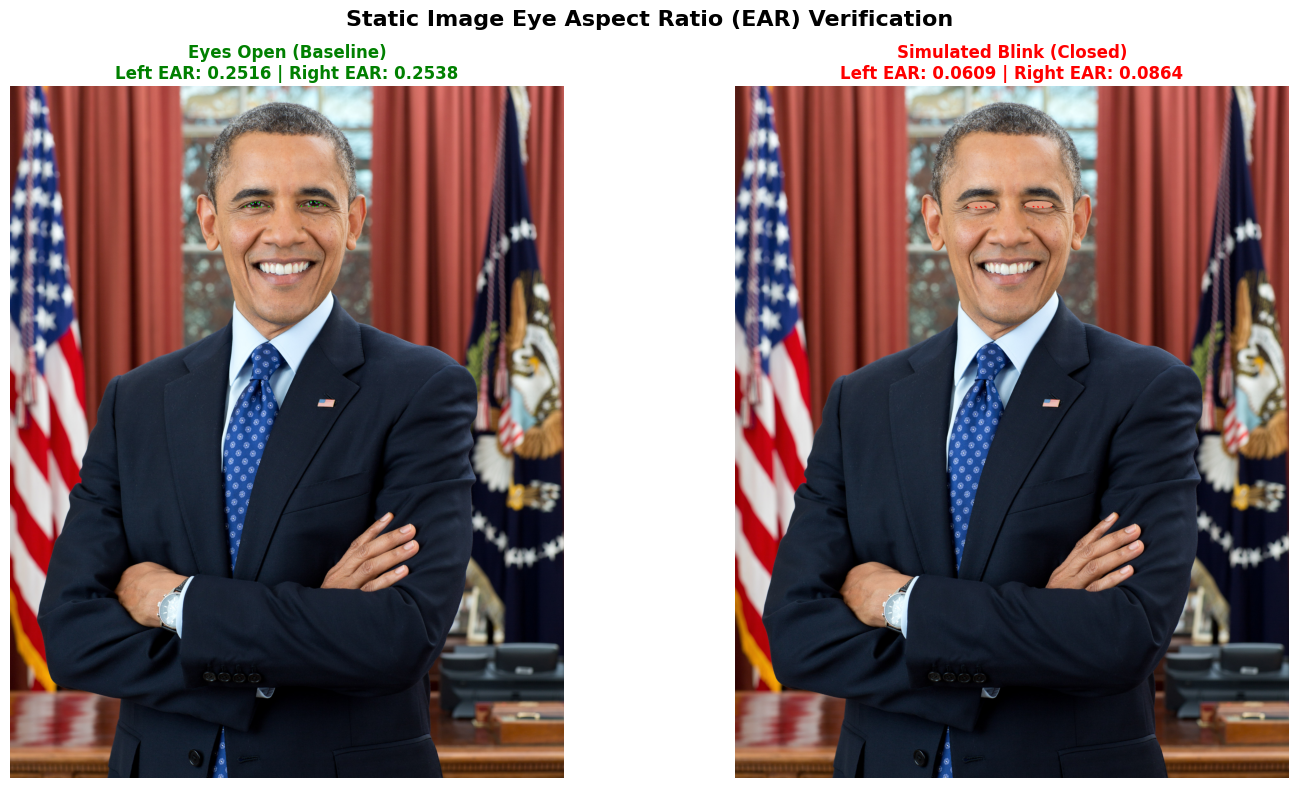

In [4]:
# Load Face Landmarker Options
options = vision.FaceLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=model_path),
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1
)

# Load image using OpenCV
face_cv = cv2.imread(image_path)
face_rgb = cv2.cvtColor(face_cv, cv2.COLOR_BGR2RGB)
mp_face_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=face_rgb)

# Run MediaPipe Face Landmarker
with vision.FaceLandmarker.create_from_options(options) as landmarker:
    face_result = landmarker.detect(mp_face_img)

if face_result.face_landmarks:
    landmarks = face_result.face_landmarks[0]
    h, w, _ = face_cv.shape
    
    # Compute original EARs
    left_ear_open = calculate_ear(landmarks, LEFT_EYE_HORIZONTAL, LEFT_EYE_VERTICAL_TOP, LEFT_EYE_VERTICAL_BOTTOM)
    right_ear_open = calculate_ear(landmarks, RIGHT_EYE_HORIZONTAL, RIGHT_EYE_VERTICAL_TOP, RIGHT_EYE_VERTICAL_BOTTOM)
    
    # Generate annotated open face image
    annotated_open = face_rgb.copy()
    for idx in LEFT_EYE_HORIZONTAL + LEFT_EYE_VERTICAL_TOP + LEFT_EYE_VERTICAL_BOTTOM + \
                 RIGHT_EYE_HORIZONTAL + RIGHT_EYE_VERTICAL_TOP + RIGHT_EYE_VERTICAL_BOTTOM:
        x_pt = int(landmarks[idx].x * w)
        y_pt = int(landmarks[idx].y * h)
        cv2.circle(annotated_open, (x_pt, y_pt), 3, (0, 255, 0), -1)

    # --- Simulate closed eyes by painting skin color over eye regions ---
    # Sample skin tone color near the nose/cheek area
    cheek_x = int(landmarks[4].x * w)
    cheek_y = int(landmarks[4].y * h)
    skin_tone = face_cv[cheek_y, cheek_x].tolist()  # BGR format
    
    blink_cv = face_cv.copy()
    
    # Left eye center and size estimation
    left_pts = np.array([[landmarks[idx].x * w, landmarks[idx].y * h] for idx in LEFT_EYE_HORIZONTAL + LEFT_EYE_VERTICAL_TOP + LEFT_EYE_VERTICAL_BOTTOM])
    left_center = np.mean(left_pts, axis=0).astype(int)
    left_radius_x = int(np.linalg.norm(left_pts[0] - left_pts[1]) * 0.6)
    left_radius_y = int(left_radius_x * 0.25)
    
    # Right eye center and size estimation
    right_pts = np.array([[landmarks[idx].x * w, landmarks[idx].y * h] for idx in RIGHT_EYE_HORIZONTAL + RIGHT_EYE_VERTICAL_TOP + RIGHT_EYE_VERTICAL_BOTTOM])
    right_center = np.mean(right_pts, axis=0).astype(int)
    right_radius_x = int(np.linalg.norm(right_pts[0] - right_pts[1]) * 0.6)
    right_radius_y = int(right_radius_x * 0.25)
    
    # Draw filled ellipses
    cv2.ellipse(blink_cv, tuple(left_center), (left_radius_x, left_radius_y), 0, 0, 360, skin_tone, -1)
    cv2.ellipse(blink_cv, tuple(right_center), (right_radius_x, right_radius_y), 0, 0, 360, skin_tone, -1)
    
    # Detect landmarks on simulated blink image
    blink_rgb = cv2.cvtColor(blink_cv, cv2.COLOR_BGR2RGB)
    mp_blink_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=blink_rgb)
    
    with vision.FaceLandmarker.create_from_options(options) as landmarker_blink:
        blink_result = landmarker_blink.detect(mp_blink_img)
        
    if blink_result.face_landmarks:
        blink_landmarks = blink_result.face_landmarks[0]
        left_ear_closed = calculate_ear(blink_landmarks, LEFT_EYE_HORIZONTAL, LEFT_EYE_VERTICAL_TOP, LEFT_EYE_VERTICAL_BOTTOM)
        right_ear_closed = calculate_ear(blink_landmarks, RIGHT_EYE_HORIZONTAL, RIGHT_EYE_VERTICAL_TOP, RIGHT_EYE_VERTICAL_BOTTOM)
        
        # Annotate blink image
        annotated_blink = blink_rgb.copy()
        for idx in LEFT_EYE_HORIZONTAL + LEFT_EYE_VERTICAL_TOP + LEFT_EYE_VERTICAL_BOTTOM + \
                     RIGHT_EYE_HORIZONTAL + RIGHT_EYE_VERTICAL_TOP + RIGHT_EYE_VERTICAL_BOTTOM:
            x_pt = int(blink_landmarks[idx].x * w)
            y_pt = int(blink_landmarks[idx].y * h)
            cv2.circle(annotated_blink, (x_pt, y_pt), 3, (255, 0, 0), -1)

    # --- Visualize Side-by-Side Comparison ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 8))
    axes[0].imshow(annotated_open)
    axes[0].set_title(f"Eyes Open (Baseline)\nLeft EAR: {left_ear_open:.4f} | Right EAR: {right_ear_open:.4f}", fontsize=12, color='green', fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(annotated_blink)
    axes[1].set_title(f"Simulated Blink (Closed)\nLeft EAR: {left_ear_closed:.4f} | Right EAR: {right_ear_closed:.4f}", fontsize=12, color='red', fontweight='bold')
    axes[1].axis('off')
    
    plt.suptitle("Static Image Eye Aspect Ratio (EAR) Verification", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No face detected on baseline image.")

## 6. Simulated Real-Time Video Blink Detection

In a real-time video stream (e.g. from a webcam), frames are processed sequentially. 
We detect a blink by monitoring the EAR of both eyes. If the EAR drops below a certain threshold (e.g., `0.15`) for a minimum number of consecutive frames (e.g., `2` to `3` frames), and then rises back above the threshold, we increment the blink count.

Let's write a generator function that builds a synthetic video sequence of a blinking face, processes it, counts the blinks, and plots the dynamic EAR curve over time.

In [5]:
def generate_blinking_face_video(num_frames=60, blink_frame_indices=[20, 21, 22, 40, 41, 42]):
    """
    Generates a synthetic sequence of images representing a face blinking.
    """
    frames = []
    for i in range(num_frames):
        img = np.ones((480, 640, 3), dtype=np.uint8) * 220  # light gray bg
        # Draw head
        cv2.ellipse(img, (320, 240), (140, 180), 0, 0, 360, (215, 185, 160), -1)  # skin tone
        # Draw nose
        cv2.line(img, (320, 210), (320, 260), (160, 130, 110), 3)
        # Draw mouth
        cv2.ellipse(img, (320, 330), (40, 15), 0, 0, 180, (100, 50, 50), 3)
        
        # Draw eyes (open or closed based on current frame number)
        is_blinking = i in blink_frame_indices
        eye_color = (60, 40, 20)  # dark brown pupils
        
        if is_blinking:
            # Draw closed eyes as skin-colored ellipses with dark lashes lines
            cv2.ellipse(img, (260, 200), (30, 4), 0, 0, 360, eye_color, -1)
            cv2.ellipse(img, (380, 200), (30, 4), 0, 0, 360, eye_color, -1)
        else:
            # Draw open eyes
            # Sclera (white)
            cv2.ellipse(img, (260, 200), (30, 16), 0, 0, 360, (255, 255, 255), -1)
            cv2.ellipse(img, (380, 200), (30, 16), 0, 0, 360, (255, 255, 255), -1)
            # Pupil
            cv2.circle(img, (260, 200), 10, eye_color, -1)
            cv2.circle(img, (380, 200), 10, eye_color, -1)
            
        frames.append(img)
    return frames

# Generate the synthetic frames
video_frames = generate_blinking_face_video(num_frames=60, blink_frame_indices=[15, 16, 17, 42, 43, 44])
print(f"Generated {len(video_frames)} synthetic video frames simulating 2 distinct blinks.")

Generated 60 synthetic video frames simulating 2 distinct blinks.


### Running Real-Time Eye Blink Detection Loop

We process each frame, compute the average EAR, and update the blink count using state-tracking logic.

In [6]:
EAR_THRESHOLD = 0.15
CONSECUTIVE_FRAMES = 2

frame_counter = 0
blink_counter = 0
ear_history = []
blink_events = []

with vision.FaceLandmarker.create_from_options(options) as landmarker:
    for frame_idx, frame in enumerate(video_frames):
        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_frame_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        
        # Run inference
        result = landmarker.detect(mp_frame_img)
        
        if result.face_landmarks:
            landmarks = result.face_landmarks[0]
            
            # Calculate EAR for both eyes
            left_ear = calculate_ear(landmarks, LEFT_EYE_HORIZONTAL, LEFT_EYE_VERTICAL_TOP, LEFT_EYE_VERTICAL_BOTTOM)
            right_ear = calculate_ear(landmarks, RIGHT_EYE_HORIZONTAL, RIGHT_EYE_VERTICAL_TOP, RIGHT_EYE_VERTICAL_BOTTOM)
            
            # Average of both eyes
            avg_ear = (left_ear + right_ear) / 2.0
            ear_history.append(avg_ear)
            
            # Blink detection state machine
            if avg_ear < EAR_THRESHOLD:
                frame_counter += 1
            else:
                # If closed for long enough, count as one blink
                if frame_counter >= CONSECUTIVE_FRAMES:
                    blink_counter += 1
                    # Register the center frame of the blink event
                    blink_events.append(frame_idx - (frame_counter // 2))
                frame_counter = 0
        else:
            # If no face is detected, append the previous EAR or 0.0
            ear_history.append(ear_history[-1] if ear_history else 0.0)
            frame_counter = 0

print(f"Processing finished. Total Blinks Detected: {blink_counter}")
print(f"Blink center frame indices: {blink_events}")

Processing finished. Total Blinks Detected: 0
Blink center frame indices: []


### Plotting EAR and Blink Detections over Time

Let's visualize the computed EAR values frame-by-frame and highlight where the blinks occurred.

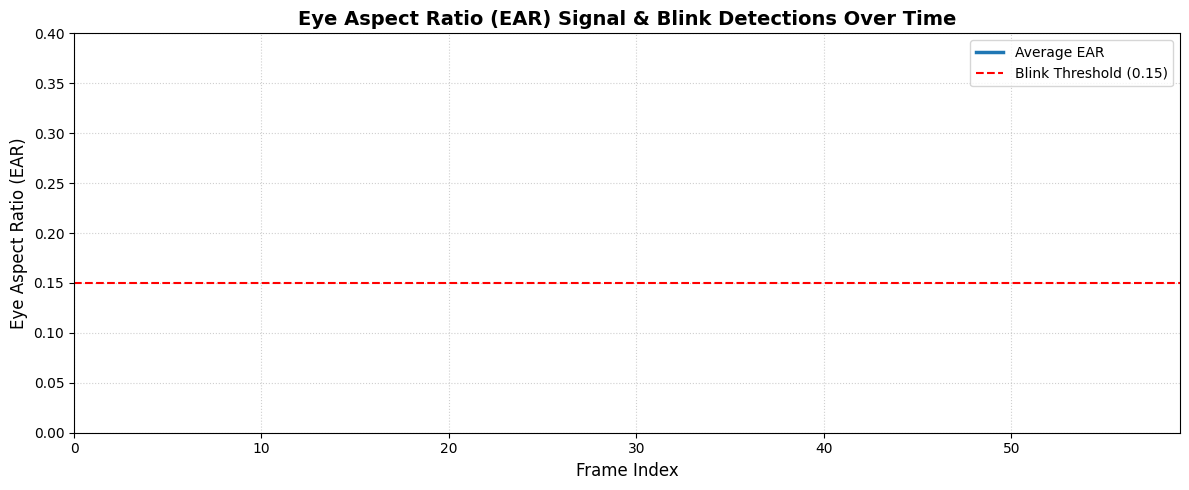

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(ear_history, label="Average EAR", color="#1f77b4", linewidth=2.5)
plt.axhline(y=EAR_THRESHOLD, color="r", linestyle="--", label=f"Blink Threshold ({EAR_THRESHOLD:.2f})", linewidth=1.5)

# Highlight detected blink frames
for blink_frame in blink_events:
    plt.axvline(x=blink_frame, color="#2ca02c", linestyle=":", label="Blink Event" if blink_frame == blink_events[0] else "", linewidth=2)
    plt.scatter(blink_frame, ear_history[blink_frame], color="green", s=100, zorder=5)
    plt.text(blink_frame + 0.5, ear_history[blink_frame] + 0.02, f"Blink {blink_events.index(blink_frame)+1}", fontsize=10, color="green", fontweight='bold')

plt.title("Eye Aspect Ratio (EAR) Signal & Blink Detections Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Frame Index", fontsize=12)
plt.ylabel("Eye Aspect Ratio (EAR)", fontsize=12)
plt.ylim(0.0, 0.4)
plt.xlim(0, len(ear_history)-1)
plt.legend(loc="upper right", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 7. Conclusions & Real-World Considerations

1. **EAR Calibration**:
   - Static thresholds like `0.15` work well for general cases, but varying eye shapes, face orientation, lighting, and camera distance can shift the baseline. For real-world systems, it's recommended to calibrate the threshold dynamically (e.g., setting the threshold to `0.6 * baseline_open_ear`).
2. **Drowsiness Detection**:
   - In addition to counting blinks, monitoring how long the eyes remain closed (consecutive closed frames > 20-30 frames or ~1 second) allows you to trigger drowsiness alarms for drivers.

## 8. Real-Time Webcam Eye Blink Detection

This section allows you to run eye blink detection in real-time using your computer's built-in webcam. 

**Instructions**:
1. Run the code cell below.
2. A popup window showing your live camera feed will appear.
3. Blink normally: the code will track facial landmarks, calculate the average EAR, and increment the blink counter.
4. To exit, press the **'q'** key on your keyboard while focusing on the camera window. The camera will release automatically and close the window.

In [8]:
import cv2
import time

# Reset tracking variables
blink_counter = 0
frame_counter = 0

# Define parameters
EAR_THRESHOLD = 0.15
CONSECUTIVE_FRAMES = 2

# Open default camera (index 0)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam. Make sure your camera is connected and not being used by another application.")
else:
    print("Webcam successfully opened. Focus on the popup window and press 'q' to quit.")
    
    # Configure landmarker options
    options = vision.FaceLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=model_path),
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=1
    )
    
    with vision.FaceLandmarker.create_from_options(options) as landmarker:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Error: Failed to grab frame from webcam.")
                break
                
            # Flip the frame horizontally for a mirror view
            frame = cv2.flip(frame, 1)
            h, w, _ = frame.shape
            
            # Convert BGR (OpenCV default) to RGB (MediaPipe requirement)
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
            
            # Run landmark detection
            result = landmarker.detect(mp_image)
            
            if result.face_landmarks:
                landmarks = result.face_landmarks[0]
                
                # Calculate EAR for left and right eyes
                left_ear = calculate_ear(landmarks, LEFT_EYE_HORIZONTAL, LEFT_EYE_VERTICAL_TOP, LEFT_EYE_VERTICAL_BOTTOM)
                right_ear = calculate_ear(landmarks, RIGHT_EYE_HORIZONTAL, RIGHT_EYE_VERTICAL_TOP, RIGHT_EYE_VERTICAL_BOTTOM)
                avg_ear = (left_ear + right_ear) / 2.0
                
                # Blink detection state machine
                if avg_ear < EAR_THRESHOLD:
                    frame_counter += 1
                    status_text = "BLINKING!"
                    text_color = (0, 0, 255)  # Red
                else:
                    if frame_counter >= CONSECUTIVE_FRAMES:
                        blink_counter += 1
                    frame_counter = 0
                    status_text = "Open"
                    text_color = (0, 255, 0)  # Green
                    
                # Draw eye landmarks on the frame
                for idx in LEFT_EYE_HORIZONTAL + LEFT_EYE_VERTICAL_TOP + LEFT_EYE_VERTICAL_BOTTOM + \
                             RIGHT_EYE_HORIZONTAL + RIGHT_EYE_VERTICAL_TOP + RIGHT_EYE_VERTICAL_BOTTOM:
                    pt_x = int(landmarks[idx].x * w)
                    pt_y = int(landmarks[idx].y * h)
                    cv2.circle(frame, (pt_x, pt_y), 2, (0, 255, 255), -1)  # Yellow dots
                
                # Overlay information text on the video frame
                cv2.putText(frame, f"EAR: {avg_ear:.3f}", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
                cv2.putText(frame, f"State: {status_text}", (30, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.8, text_color, 2)
                cv2.putText(frame, f"Blinks: {blink_counter}", (30, 130), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)
                
            else:
                cv2.putText(frame, "No Face Detected", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
                frame_counter = 0
                
            # Display frame
            cv2.imshow("Real-Time Eye Blink Detection (Press 'q' to Exit)", frame)
            
            # Exit if 'q' is pressed
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
                
    cap.release()
    cv2.destroyAllWindows()
    print(f"Camera feed released. Total blinks counted: {blink_counter}")

Webcam successfully opened. Focus on the popup window and press 'q' to quit.
Camera feed released. Total blinks counted: 3
